# Imports and functions

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import ks_2samp
from scipy import stats  

In [2]:
def load_and_filter_data(sim_dir, scenarios, rain_filter_threshold, shift_threshold):
    """
    Load and filter data for selected urbanization scenarios.
    
    Parameters:
    sim_dir (str): Directory containing pickle files
    scenarios (list): List of scenario labels to analyze
    rain_filter_threshold (float): Threshold for filtering rain events
    shift_threshold (int): Threshold for shift range calculation
    
    Returns:
    dict: Dictionary containing historical and future data for each scenario
    """
    data_dict = {}
    
    # Define all available scenarios

    all_scenarios = [
    # Historical rain with urbanization
    ('rain_shift_results_control.pkl', '38% urbanization'),
    ('rain_shift_results_1_1_urbanization_historical_rain.pkl', '42% urbanization'),
    ('rain_shift_results_1_2_urbanization_historical_rain.pkl', '46% urbanization'),
    ('rain_shift_results_1_3_urbanization_historical_rain.pkl', '49% urbanization'),
    ('rain_shift_results_1_4_urbanization_historical_rain.pkl', '53% urbanization'),
    ('rain_shift_results_1_5_urbanization_historical_rain.pkl', '57% urbanization'),
    ('rain_shift_results_2_0_urbanization_historical_rain.pkl', '73% urbanization'),
    ('rain_shift_results_3_0_urbanization_historical_rain.pkl', '81% urbanization'),
    ('rain_shift_results_5_0_urbanization_historical_rain.pkl', '87% urbanization'),
        
    # Climate Change with urbanization       
    ('rain_shift_results_1_0_urbanization.pkl', 'Climate Change 38% urbanization'),
    ('rain_shift_results_1_1_urbanization.pkl', 'Climate Change 42% urbanization'),
    ('rain_shift_results_1_2_urbanization.pkl', 'Climate Change 46% urbanization'),
    ('rain_shift_results_1_3_urbanization.pkl', 'Climate Change 49% urbanization'),
    ('rain_shift_results_1_4_urbanization.pkl', 'Climate Change 53% urbanization'),
    ('rain_shift_results_1_5_urbanization.pkl', 'Climate Change 57% urbanization'),
    ('rain_shift_results_2_0_urbanization.pkl', 'Climate Change 73% urbanization'),
    ('rain_shift_results_3_0_urbanization.pkl', 'Climate Change 81% urbanization'),
    ('rain_shift_results_5_0_urbanization.pkl', 'Climate Change 87% urbanization'),
        
    ]

    # Filter scenarios based on user selection
    selected_scenarios = [(pkl, label) for pkl, label in all_scenarios if label in scenarios]
    
    for pickle_file, label_name in selected_scenarios:
        pickle_file_path = os.path.join(sim_dir, pickle_file)
        
        # Load and filter data
        final_results_df = pd.read_pickle(pickle_file_path)
        filtered_df, _, _ = filter_events_by_rainfall(
            final_results_df, 
            rain_filter_threshold, 
            shift_threshold
        )
        
        # Extract historical and future values
        data_dict[label_name] = {
            'historical': filtered_df[historical_column].values,
            'future': filtered_df[future_column].values
        }
        
    return data_dict

In [3]:
def filter_events_by_rainfall(final_results_df, rain_filter_threshold, shift_threshold):
    """
    Filter out events with total rainfall below threshold and shifts beyond threshold.
    """
    event_nums_to_filter_out = []
    
    for event in final_results_df['event_num'].unique():
        event_df = final_results_df[final_results_df['event_num'] == event]
        
        # Check rain threshold
        rain_condition = (
            (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and 
            (event_df[('future', 'full_basin', 'total_rain')] < rain_filter_threshold).all()
        )
        
        # Check shift threshold
        historical_discharge = event_df[('historical', 'basin discharge', 'max_discharge')].values
        future_discharge = event_df[('future', 'basin discharge', 'max_discharge')].values
        shift_condition = abs(future_discharge - historical_discharge) > shift_threshold
        
        if rain_condition or shift_condition.any():
            event_nums_to_filter_out.append(event)
    
    filtered_df = final_results_df[~final_results_df['event_num'].isin(event_nums_to_filter_out)]
    y_shift_range = np.arange(-shift_threshold, shift_threshold + 1, 500)
    filtered_df = filtered_df[filtered_df[('y', '', '')].isin(y_shift_range)]
    num_classes = 2
    print(f'number of events that filtered out: {len(event_nums_to_filter_out)}')
    return filtered_df, y_shift_range, num_classes

In [4]:
def ks_test_for_scenario(data_dict, scenario):
    """
    Perform the Two-sample Kolmogorov-Smirnov test between future and historical data for a given scenario.
    
    Parameters:
    - data_dict (dict): Dictionary containing 'historical' and 'future' data for each scenario.
    - scenario (str): The label of the scenario to analyze (e.g., '39% urbanization').
    
    Returns:
    None: Prints the KS statistic and p-value along with an interpretation.
    """
    if scenario not in data_dict:
        print(f"Error: Scenario '{scenario}' not found in data_dict.")
        return
    
    # Extract future and historical data
    future_data = data_dict[scenario]['future']
    historical_data = data_dict[scenario]['historical']
    
    # Perform KS test
    ks_stat, p_value = ks_2samp(future_data, historical_data)
    
    # Print results
    print(f"KS Test Between Future and Historical Data ({scenario}):")
    print(f"KS Statistic: {ks_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Interpretation
    if p_value < 0.05:
        print("The distributions are significantly different.")
    else:
        print("No significant difference between the distributions.")


## MultiIndex([( 'event_num',                       '',                      ''),
            (         'x',                       '',                      ''),
            (         'y',                       '',                      ''),
            (         'd',                       '',                      ''),
            ('historical',        'basin discharge',       'total_discharge'),
            ('historical',        'basin discharge',         'max_discharge'),
            ('historical',        'basin discharge', 'swmm_max_outflow_time'),
            ('historical',        'basin discharge',    'runoff_coefficient'),
            ('historical',             'full_basin',   'max_10min_intensity'),
            ('historical',             'full_basin',   'max_20min_intensity'),
            ('historical',             'full_basin',   'max_30min_intensity'),
            ('historical',             'full_basin',   'max_60min_intensity'),
            ('historical',             'full_basin',  'max_120min_intensity'),
            ('historical',             'full_basin',  'max_240min_intensity'),
            ('historical',             'full_basin',  'max_360min_intensity'),
            ('historical',             'full_basin',  'max_720min_intensity'),
            ('historical',             'full_basin', 'max_1440min_intensity'),
            ('historical',             'full_basin',            'total_rain'),
            ('historical',            'before_peak',   'max_10min_intensity'),
            ('historical',            'before_peak',   'max_20min_intensity'),
            ('historical',            'before_peak',   'max_30min_intensity'),
            ('historical',            'before_peak',   'max_60min_intensity'),
            ('historical',            'before_peak',  'max_120min_intensity'),
            ('historical',            'before_peak',  'max_240min_intensity'),
            ('historical',            'before_peak',  'max_360min_intensity'),
            ('historical',            'before_peak',  'max_720min_intensity'),
            ('historical',            'before_peak', 'max_1440min_intensity'),
            ('historical',            'before_peak',            'total_rain'),
            ('historical',  'singular_subcatchment',   'max_10min_intensity'),
            ('historical',  'singular_subcatchment',   'max_20min_intensity'),
            ('historical',  'singular_subcatchment',   'max_30min_intensity'),
            ('historical',  'singular_subcatchment',   'max_60min_intensity'),
            ('historical',  'singular_subcatchment',  'max_120min_intensity'),
            ('historical',  'singular_subcatchment',  'max_240min_intensity'),
            ('historical',  'singular_subcatchment',  'max_360min_intensity'),
            ('historical',  'singular_subcatchment',  'max_720min_intensity'),
            ('historical',  'singular_subcatchment', 'max_1440min_intensity'),
            ('historical',  'singular_subcatchment',            'total_rain'),
            ('historical', 'Max_Specific_Discharge',         'max_discharge'),
            ('historical', 'Max_Specific_Discharge',       'total_discharge'),
            ('historical', 'Max_Specific_Discharge',    'runoff_coefficient'),
            ('historical', 'Min_Specific_Discharge',         'max_discharge'),
            ('historical', 'Min_Specific_Discharge',       'total_discharge'),
            ('historical', 'Min_Specific_Discharge',    'runoff_coefficient'),
            ('historical',         'Most_Urban_S27',         'max_discharge'),
            ('historical',         'Most_Urban_S27',       'total_discharge'),
            ('historical',         'Most_Urban_S27',    'runoff_coefficient'),
            ('historical',        'Least_Urban_S28',         'max_discharge'),
            ('historical',        'Least_Urban_S28',       'total_discharge'),
            ('historical',        'Least_Urban_S28',    'runoff_coefficient'),
            (    'future',        'basin discharge',       'total_discharge'),
            (    'future',        'basin discharge',         'max_discharge'),
            (    'future',        'basin discharge', 'swmm_max_outflow_time'),
            (    'future',        'basin discharge',    'runoff_coefficient'),
            (    'future',             'full_basin',   'max_10min_intensity'),
            (    'future',             'full_basin',   'max_20min_intensity'),
            (    'future',             'full_basin',   'max_30min_intensity'),
            (    'future',             'full_basin',   'max_60min_intensity'),
            (    'future',             'full_basin',  'max_120min_intensity'),
            (    'future',             'full_basin',  'max_240min_intensity'),
            (    'future',             'full_basin',  'max_360min_intensity'),
            (    'future',             'full_basin',  'max_720min_intensity'),
            (    'future',             'full_basin', 'max_1440min_intensity'),
            (    'future',             'full_basin',            'total_rain'),
            (    'future',            'before_peak',   'max_10min_intensity'),
            (    'future',            'before_peak',   'max_20min_intensity'),
            (    'future',            'before_peak',   'max_30min_intensity'),
            (    'future',            'before_peak',   'max_60min_intensity'),
            (    'future',            'before_peak',  'max_120min_intensity'),
            (    'future',            'before_peak',  'max_240min_intensity'),
            (    'future',            'before_peak',  'max_360min_intensity'),
            (    'future',            'before_peak',  'max_720min_intensity'),
            (    'future',            'before_peak', 'max_1440min_intensity'),
            (    'future',            'before_peak',            'total_rain'),
            (    'future',  'singular_subcatchment',   'max_10min_intensity'),
            (    'future',  'singular_subcatchment',   'max_20min_intensity'),
            (    'future',  'singular_subcatchment',   'max_30min_intensity'),
            (    'future',  'singular_subcatchment',   'max_60min_intensity'),
            (    'future',  'singular_subcatchment',  'max_120min_intensity'),
            (    'future',  'singular_subcatchment',  'max_240min_intensity'),
            (    'future',  'singular_subcatchment',  'max_360min_intensity'),
            (    'future',  'singular_subcatchment',  'max_720min_intensity'),
            (    'future',  'singular_subcatchment', 'max_1440min_intensity'),
            (    'future',  'singular_subcatchment',            'total_rain'),
            (    'future', 'Max_Specific_Discharge',         'max_discharge'),
            (    'future', 'Max_Specific_Discharge',       'total_discharge'),
            (    'future', 'Max_Specific_Discharge',    'runoff_coefficient'),
            (    'future', 'Min_Specific_Discharge',         'max_discharge'),
            (    'future', 'Min_Specific_Discharge',       'total_discharge'),
            (    'future', 'Min_Specific_Discharge',    'runoff_coefficient'),
            (    'future',         'Most_Urban_S27',         'max_discharge'),
            (    'future',         'Most_Urban_S27',       'total_discharge'),
            (    'future',         'Most_Urban_S27',    'runoff_coefficient'),
            (    'future',        'Least_Urban_S28',         'max_discharge'),
            (    'future',        'Least_Urban_S28',       'total_discharge'),
            (    'future',        'Least_Urban_S28',    'runoff_coefficient')],
           )

In [63]:
# Configuration
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
rain_filter_threshold = 1  # mm
shift_threshold = 20000     # meters

# Define columns for analysis
historical_column = ('historical', 'basin discharge', 'max_discharge')
future_column = ('future', 'basin discharge', 'max_discharge')


# historical_column = (    'historical',             'full_basin',   'max_10min_intensity')
# future_column = (    'future',             'full_basin',   'max_10min_intensity')


# Select scenarios to compare
selected_scenarios = [
    '38% urbanization',
    '42% urbanization',
    '49% urbanization',
    '53 urbanization',
    '57% urbanization',
    '73% urbanization',
    '81% urbanization',
    '87% urbanization',
    
    'Climate Change 38% urbanization',
    'Climate Change 42% urbanization',
    'Climate Change 49% urbanization',
#     'Climate Change 53% urbanization',    
    'Climate Change 57% urbanization',   
    'Climate Change 73% urbanization',
    'Climate Change 81% urbanization',
    'Climate Change 87% urbanization',
]

# Load and process data
data_dict = load_and_filter_data(sim_dir, selected_scenarios, 
                               rain_filter_threshold, shift_threshold)

# Create plot titles
dynamic_title = f"{historical_column[1].replace('_', ' ').title()} - {historical_column[2].replace('_', ' ').title()}"
x_label = f"{historical_column[2].replace('_', ' ').title()}"


# Set global font sizes
plt.rc('font', size=14)          # Default text size
plt.rc('axes', titlesize=18)     # Title font size
plt.rc('axes', labelsize=16)     # Axes labels font size
plt.rc('legend', fontsize=14)    # Legend font size
plt.rc('xtick', labelsize=12)    # X-axis tick font size
plt.rc('ytick', labelsize=12)    # Y-axis tick font size


number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4
number of events that filtered out: 4


## Two-sample Kolmogorov–Smirnov test

# PLOT

C:\Users\raznu\AppData\Local\Temp\ipykernel_22328\4055593691.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


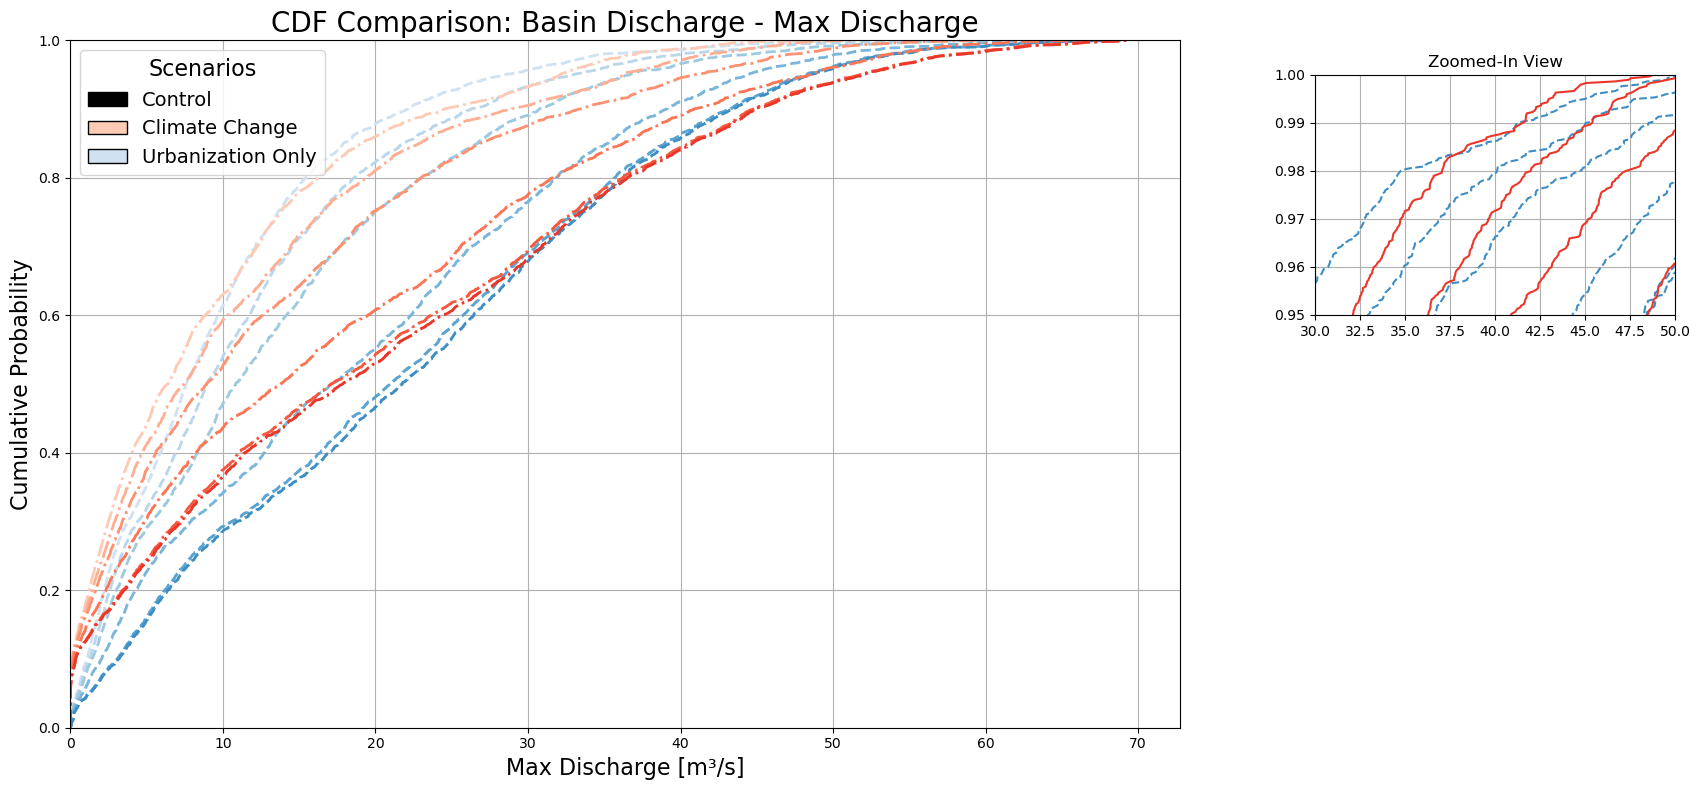

In [64]:
# Updated CDF Comparison with Zoomed-In Inset and Larger Fonts
chosen_unit = 'm³/s'
title = f'CDF Comparison: {dynamic_title}'
x_label = f"Max Discharge [{chosen_unit}]"

# Reset to default style
plt.style.use('default')

# Create the main CDF plot
plt.figure(figsize=(12, 8))

# Define color maps for scenarios with better separation
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues

# Track indices for color assignment
climate_change_index, no_climate_change_index = 0, 0

for label, scenario_data in data_dict.items():
    if label == 'Control':
        # Plot the Control data as a solid black line
        plt.plot(
            np.sort(scenario_data['future']),
            np.linspace(0, 1, len(scenario_data['future']), endpoint=True),
            label='Control',
            color='black',
            linestyle='-',
            linewidth=4
        )
    elif 'climate change' in label.lower():
        # Highlight scenarios containing 'climate change' with red tones
        plt.plot(
            np.sort(scenario_data['future']),
            np.linspace(0, 1, len(scenario_data['future']), endpoint=True),
            label=None,  # No need for repetitive labels
            color=colors_climate_change[climate_change_index],
            linestyle='-.',  # Dash-dot line
            linewidth=2
        )
        climate_change_index += 1
    else:
        # Highlight scenarios without 'climate change' with blue tones
        plt.plot(
            np.sort(scenario_data['future']),
            np.linspace(0, 1, len(scenario_data['future']), endpoint=True),
            label=None,  # No need for repetitive labels
            color=colors_no_climate_change[no_climate_change_index],
            linestyle='--',  # Dashed line
            linewidth=2
        )
        no_climate_change_index += 1

# Add titles, labels, and grid
plt.title(title, fontsize=20)  # Larger title font
plt.xlabel(x_label, fontsize=16)  # Larger x-axis label font
plt.ylabel('Cumulative Probability', fontsize=16)  # Larger y-axis label font

# Simplified legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='Control'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Climate Change'),
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='Urbanization Only')
]
plt.legend(
    handles=legend_elements,
    title='Scenarios',
    fontsize=14,  # Larger legend font
    title_fontsize=16,  # Larger legend title font
    loc='upper left'
)

plt.grid(True)

# Set axis limits
plt.xlim(left=0)
plt.ylim(0, 1)

# Add zoomed inset at the top right
zoom_inset = plt.axes([1.1, 0.6, 0.3, 0.3])  # Define position of the zoomed-in inset
for label, scenario_data in data_dict.items():
    if label == 'Control':
        zoom_inset.plot(
            np.sort(scenario_data['future']),
            np.linspace(0, 1, len(scenario_data['future']), endpoint=True),
            color='black',
            linestyle='-',
            linewidth=2
        )
    elif 'climate change' in label.lower():
        zoom_inset.plot(
            np.sort(scenario_data['future']),
            np.linspace(0, 1, len(scenario_data['future']), endpoint=True),
            color=colors_climate_change[climate_change_index - 1],
            linestyle='-',
            linewidth=1.5
        )
    else:
        zoom_inset.plot(
            np.sort(scenario_data['future']),
            np.linspace(0, 1, len(scenario_data['future']), endpoint=True),
            color=colors_no_climate_change[no_climate_change_index - 1],
            linestyle='--',
            linewidth=1.5
        )

# Set zoomed inset limits
zoom_inset.set_xlim(30, 50)  # Adjust x-axis limits for the zoomed view
zoom_inset.set_ylim(0.95, 1)  # Adjust y-axis limits for the zoomed view
zoom_inset.grid(True)
zoom_inset.set_title("Zoomed-In View", fontsize=12)  # Larger font for zoomed-in view title

# Adjust tick font sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
zoom_inset.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()


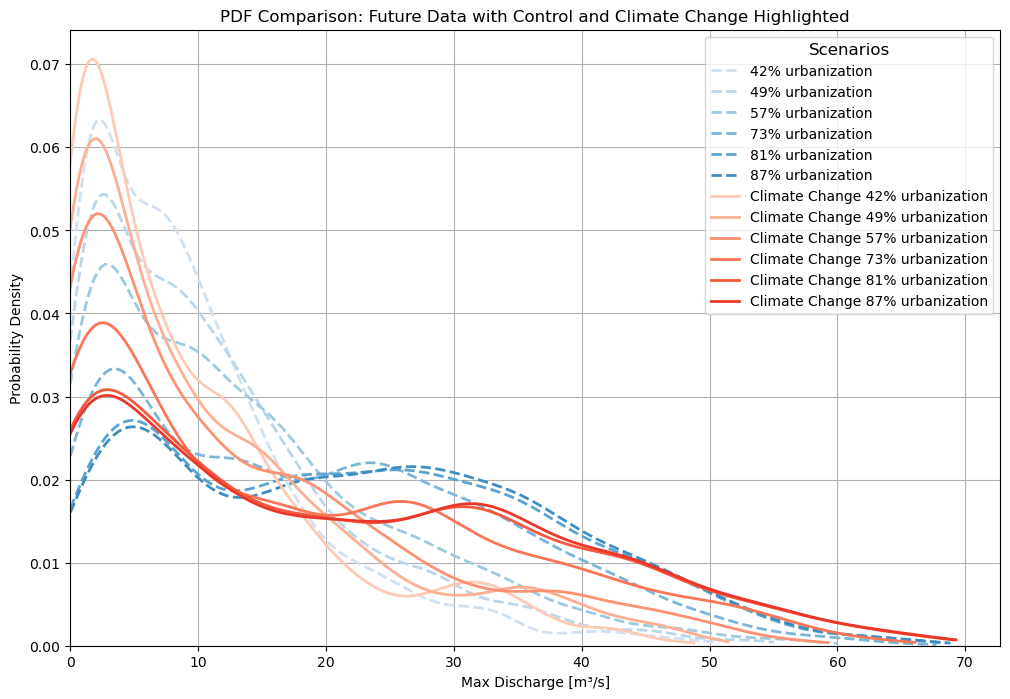

In [65]:

# Updated PDF Comparison with distinct color tones for climate change
title = 'PDF Comparison: Future Data with Control and Climate Change Highlighted'

plt.figure(figsize=(12, 8))

# Define color maps for scenarios with better separation
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues

# Track indices for color assignment
climate_change_index, no_climate_change_index = 0, 0

for label, scenario_data in data_dict.items():
    # Calculate KDE
    kde = stats.gaussian_kde(scenario_data['future'])
    x_range = np.linspace(min(scenario_data['future']), 
                         max(scenario_data['future']), 
                         200)
    
    if label == 'Control':
        # Plot the Control data as a solid black line
        plt.plot(x_range, kde(x_range),
            label=f'{label}',
            color='black',
            linestyle='-',
            linewidth=4
        )
    elif 'climate change' in label.lower():
        # Highlight scenarios containing 'climate change' with well-separated red tones
        plt.plot(x_range, kde(x_range),
            label=f'{label}',
            color=colors_climate_change[climate_change_index],
            linestyle='-',  # Dash-dot line
            linewidth=2
        )
        climate_change_index += 1
    else:
        # Highlight scenarios without 'climate change' with well-separated blue tones
        plt.plot(x_range, kde(x_range),
            label=f'{label}',
            color=colors_no_climate_change[no_climate_change_index],
            linestyle='--',  # Dashed line
            linewidth=2
        )
        no_climate_change_index += 1

# Add titles, labels, legend, and grid
plt.title(title)
plt.xlabel(x_label)
plt.ylabel('Probability Density')
plt.legend(title='Scenarios', fontsize=10, title_fontsize=12)
plt.grid(True)

# Set axis limits
plt.xlim(left=0)
plt.ylim(bottom=0)

# Show the plot
plt.show()


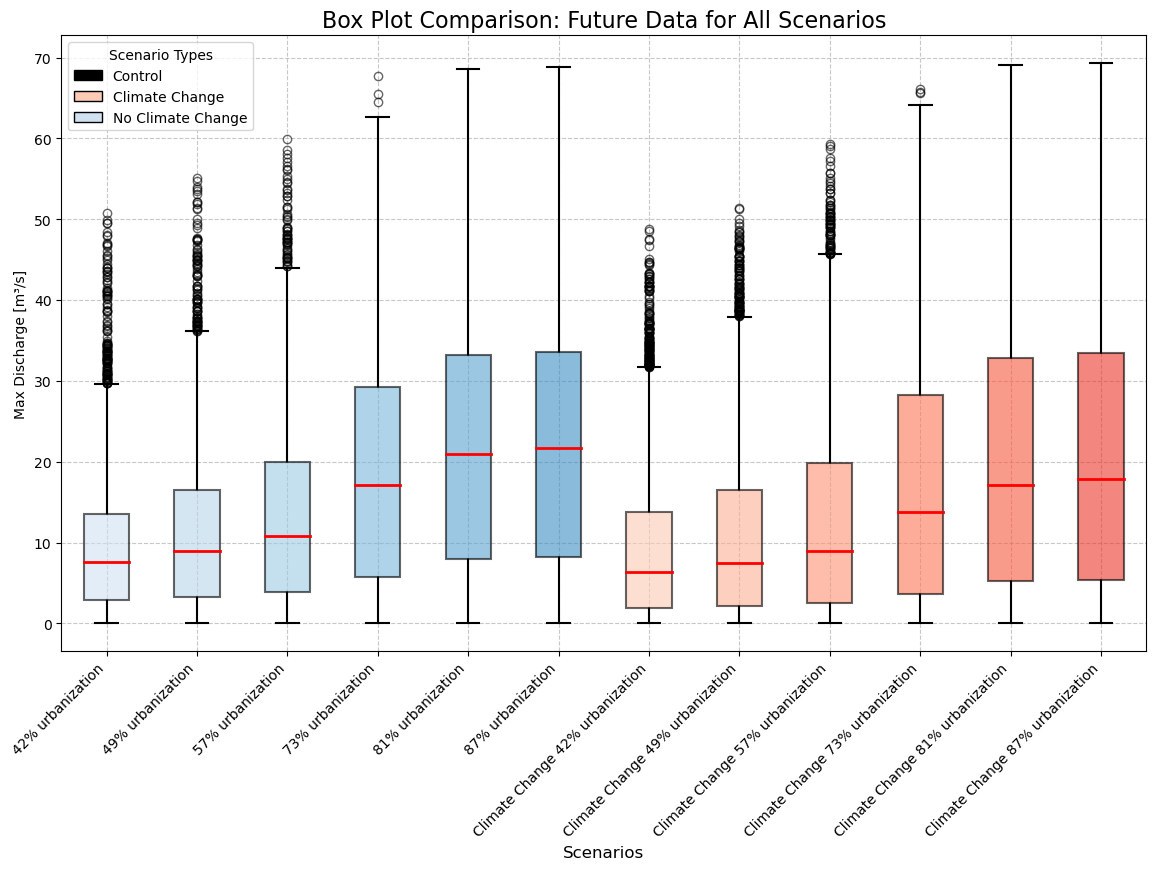

In [66]:
# Enhanced Box Plot Comparison for Future Data
title = 'Box Plot Comparison: Future Data for All Scenarios'

# Collect data for plotting
scenario_labels = []
scenario_values = []

for label, scenario_data in data_dict.items():
    scenario_labels.append(label)
    scenario_values.append(scenario_data['future'])

# Define colors for scenarios
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues
colors = []

climate_change_index, no_climate_change_index = 0, 0
for label in scenario_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[climate_change_index])
        climate_change_index += 1
    elif label == 'Control':
        colors.append('black')  # Special color for Control
    else:
        colors.append(colors_no_climate_change[no_climate_change_index])
        no_climate_change_index += 1

plt.figure(figsize=(14, 8))

# Create the boxplot with custom colors
box = plt.boxplot(scenario_values, patch_artist=True, labels=scenario_labels,
                  boxprops=dict(color='black', linewidth=1.5),  # Box border
                  whiskerprops=dict(color='black', linewidth=1.5),  # Whisker line
                  capprops=dict(color='black', linewidth=1.5),  # Caps
                  medianprops=dict(color='red', linewidth=2),  # Median line
                  flierprops=dict(marker='o', color='black', alpha=0.6))  # Outliers

# Color the boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)  # Slight transparency for better visibility

# Add titles, labels, and grid
plt.title(title, fontsize=16)
plt.ylabel(x_label)
plt.xlabel('Scenarios', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='Control'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Climate Change'),
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='No Climate Change')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Scenario Types')

# Show the plot
plt.show()


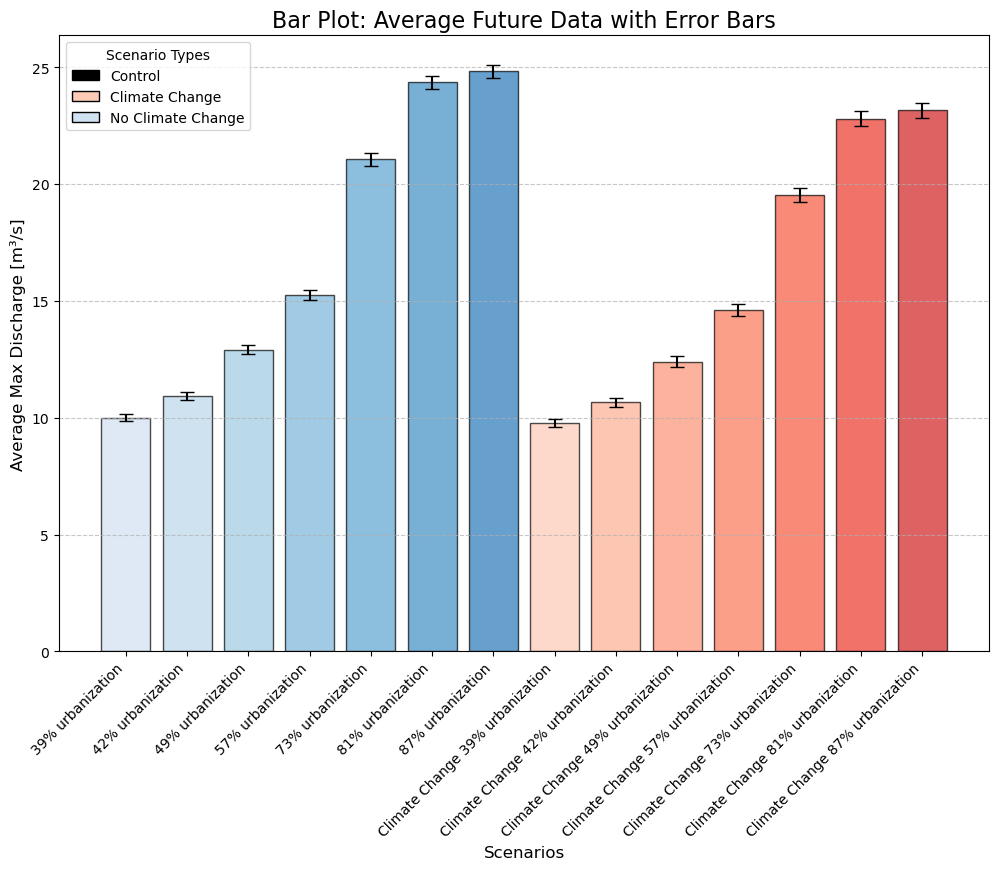

In [38]:
# Bar Plot for Average Values with Error Bars
title = 'Bar Plot: Average Future Data with Error Bars'

# Collect data for plotting
scenario_labels = []
scenario_averages = []
scenario_errors = []  # Standard error for each scenario

for label, scenario_data in data_dict.items():
    scenario_labels.append(label)
    scenario_averages.append(np.mean(scenario_data['future']))
    scenario_errors.append(np.std(scenario_data['future']) / np.sqrt(len(scenario_data['future'])))  # Standard error

# Define colors for scenarios
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues
colors = []

climate_change_index, no_climate_change_index = 0, 0
for label in scenario_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[climate_change_index])
        climate_change_index += 1
    elif label == 'Control':
        colors.append('black')  # Special color for Control
    else:
        colors.append(colors_no_climate_change[no_climate_change_index])
        no_climate_change_index += 1

plt.figure(figsize=(12, 8))
plt.bar(scenario_labels, scenario_averages, yerr=scenario_errors, color=colors, alpha=0.7, edgecolor='black', capsize=5)

# Add titles, labels, and grid
plt.title(title, fontsize=16)
plt.ylabel(f'Average {x_label}', fontsize=12)
plt.xlabel('Scenarios', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='Control'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Climate Change'),
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='No Climate Change')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Scenario Types')
# Show the plot
plt.show()


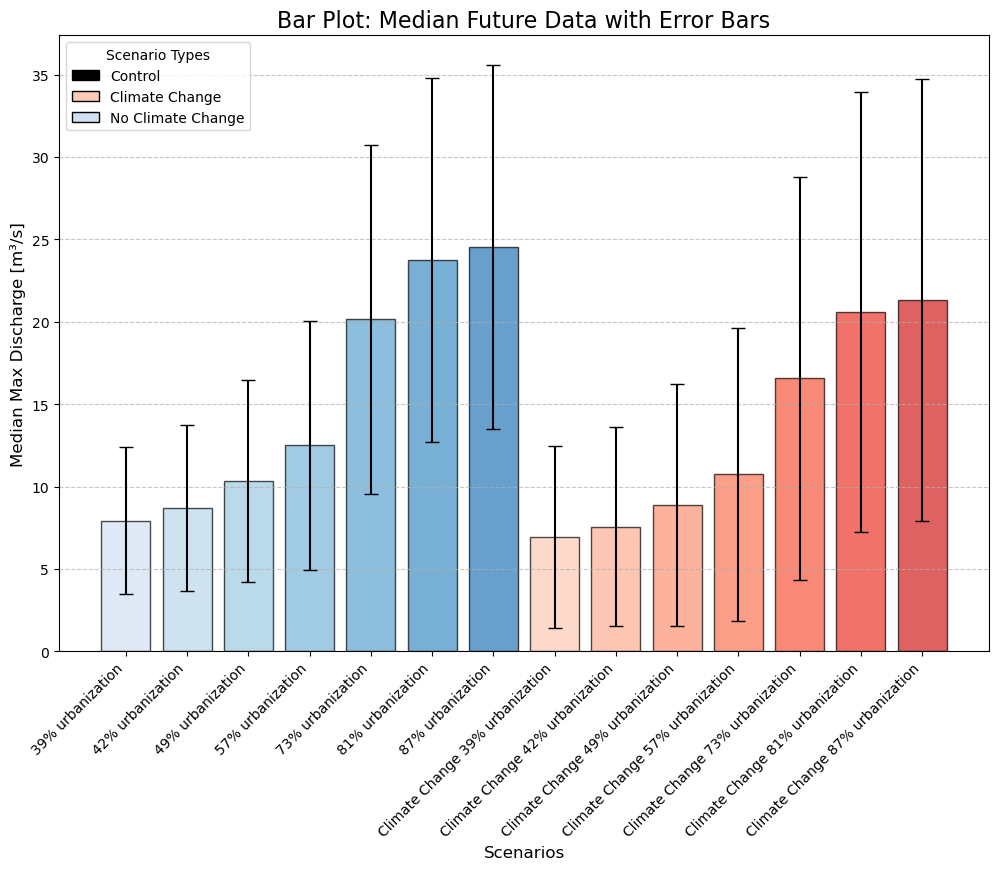

In [39]:
# Bar Plot for Median Values with Error Bars
title = 'Bar Plot: Median Future Data with Error Bars'

# Collect data for plotting
scenario_labels = []
scenario_medians = []
scenario_errors = []  # IQR for each scenario

for label, scenario_data in data_dict.items():
    scenario_labels.append(label)
    scenario_medians.append(np.median(scenario_data['future']))
    q1 = np.percentile(scenario_data['future'], 25)
    q3 = np.percentile(scenario_data['future'], 75)
    scenario_errors.append((q3 - q1) / 2)  # Half the IQR as symmetric error

# Define colors for scenarios
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues
colors = []

climate_change_index, no_climate_change_index = 0, 0
for label in scenario_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[climate_change_index])
        climate_change_index += 1
    elif label == 'Control':
        colors.append('black')  # Special color for Control
    else:
        colors.append(colors_no_climate_change[no_climate_change_index])
        no_climate_change_index += 1

plt.figure(figsize=(12, 8))
plt.bar(scenario_labels, scenario_medians, yerr=scenario_errors, color=colors, alpha=0.7, edgecolor='black', capsize=5)

# Add titles, labels, and grid
plt.title(title, fontsize=16)
plt.ylabel(f'Median {x_label}', fontsize=12)
plt.xlabel('Scenarios', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='Control'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Climate Change'),
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='No Climate Change')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Scenario Types')
# Show the plot
plt.show()


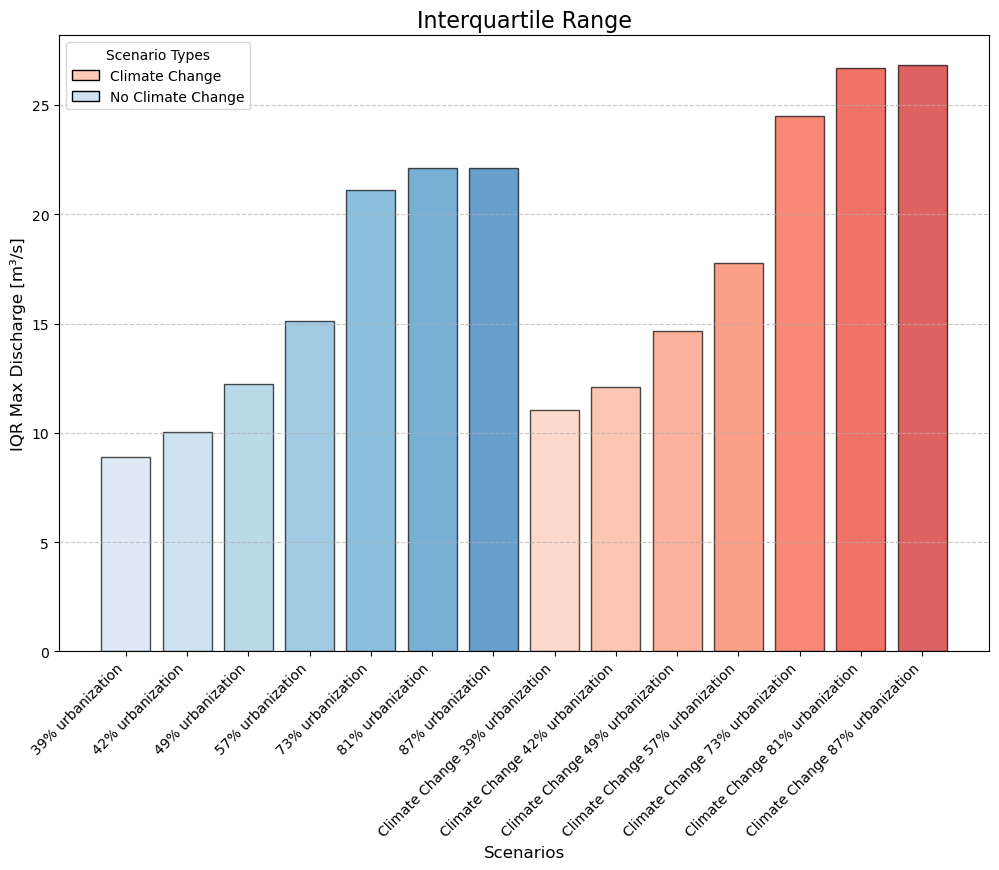

In [40]:
# Bar Plot for IQR Values
title = 'Interquartile Range'

# Collect data for plotting
scenario_labels = []
scenario_iqr = []

for label, scenario_data in data_dict.items():
    scenario_labels.append(label)
    q1 = np.percentile(scenario_data['future'], 25)
    q3 = np.percentile(scenario_data['future'], 75)
    scenario_iqr.append(q3 - q1)  # Calculate IQR

# Define colors for scenarios
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues
colors = []

climate_change_index, no_climate_change_index = 0, 0
for label in scenario_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[climate_change_index])
        climate_change_index += 1
    elif label == 'Control':
        colors.append('black')  # Special color for Control
    else:
        colors.append(colors_no_climate_change[no_climate_change_index])
        no_climate_change_index += 1

# Plot the bar chart
plt.figure(figsize=(12, 8))
plt.bar(scenario_labels, scenario_iqr, color=colors, alpha=0.7, edgecolor='black')

# Add titles, labels, and grid
plt.title(title, fontsize=16)
plt.ylabel(f'IQR {x_label}', fontsize=12)
plt.xlabel('Scenarios', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
legend_elements = [
#     Patch(facecolor='black', edgecolor='black', label='Control'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Climate Change'),
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='No Climate Change')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Scenario Types')
# Show the plot
plt.show()


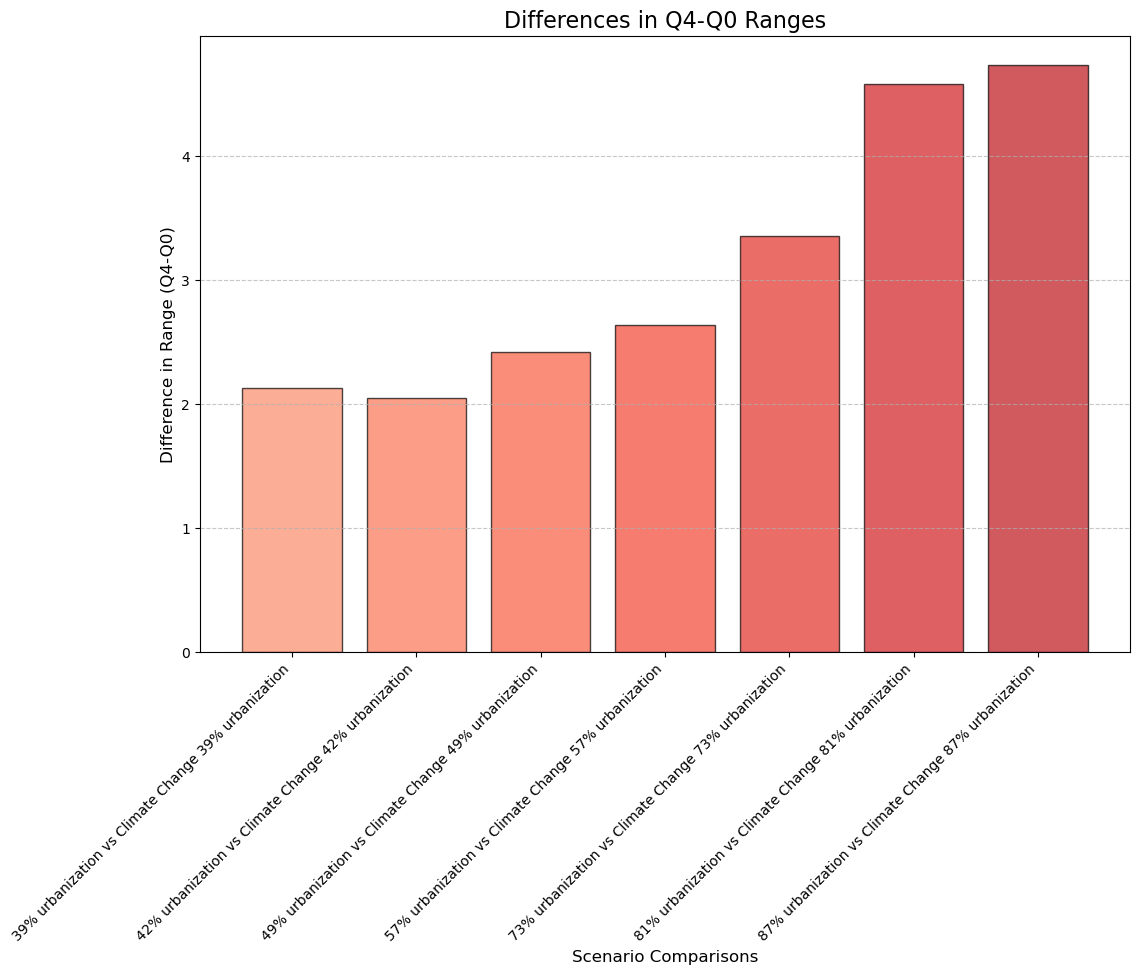

In [52]:

# Collect Q4 - Q0 ranges
scenario_labels = list(data_dict.keys())
scenario_ranges = [np.percentile(data['future'], 75) - np.percentile(data['future'], 25) for data in data_dict.values()]

# Calculate differences
half = len(scenario_ranges) // 2
difference_labels = [f'{scenario_labels[i]} vs {scenario_labels[i+half]}' for i in range(half)]
differences = [scenario_ranges[i+half] - scenario_ranges[i] for i in range(half)]

# Define colors
colors_climate_change = plt.cm.Reds(np.linspace(0.4, 0.8, half))
colors_no_climate_change = plt.cm.Blues(np.linspace(0.4, 0.8, half))
colors = []

for label in difference_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[len(colors)])
    else:
        colors.append(colors_no_climate_change[len(colors)])

# Plot the differences
plt.figure(figsize=(12, 8))
plt.bar(difference_labels, differences, color=colors, alpha=0.7, edgecolor='black')

# Add titles, labels, and grid
plt.title('Differences in Q4-Q0 Ranges', fontsize=16)
plt.ylabel('Difference in Range (Q4-Q0)', fontsize=12)
plt.xlabel('Scenario Comparisons', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

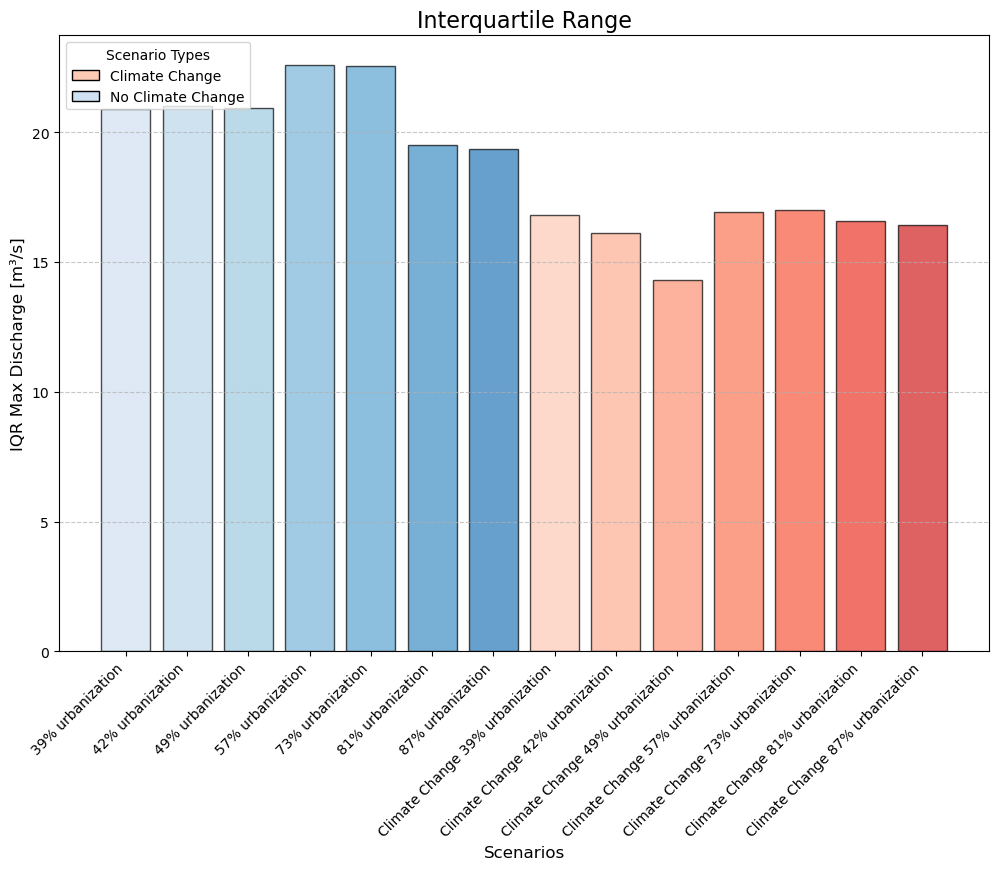

In [60]:
# Bar Plot for IQR Values
title = 'Interquartile Range'

# Collect data for plotting
scenario_labels = []
scenario_iqr = []

for label, scenario_data in data_dict.items():
    scenario_labels.append(label)
    q1 = np.percentile(scenario_data['future'], 95)
    q3 = np.percentile(scenario_data['future'], 100)
    scenario_iqr.append(q3 - q1)  # Calculate IQR

# Define colors for scenarios
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, 9))  # 9 distinct reds
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, 9))  # 9 distinct blues
colors = []

climate_change_index, no_climate_change_index = 0, 0
for label in scenario_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[climate_change_index])
        climate_change_index += 1
    elif label == 'Control':
        colors.append('black')  # Special color for Control
    else:
        colors.append(colors_no_climate_change[no_climate_change_index])
        no_climate_change_index += 1

# Plot the bar chart
plt.figure(figsize=(12, 8))
plt.bar(scenario_labels, scenario_iqr, color=colors, alpha=0.7, edgecolor='black')

# Add titles, labels, and grid
plt.title(title, fontsize=16)
plt.ylabel(f'IQR {x_label}', fontsize=12)
plt.xlabel('Scenarios', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
legend_elements = [
#     Patch(facecolor='black', edgecolor='black', label='Control'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Climate Change'),
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='No Climate Change')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Scenario Types')
# Show the plot
plt.show()


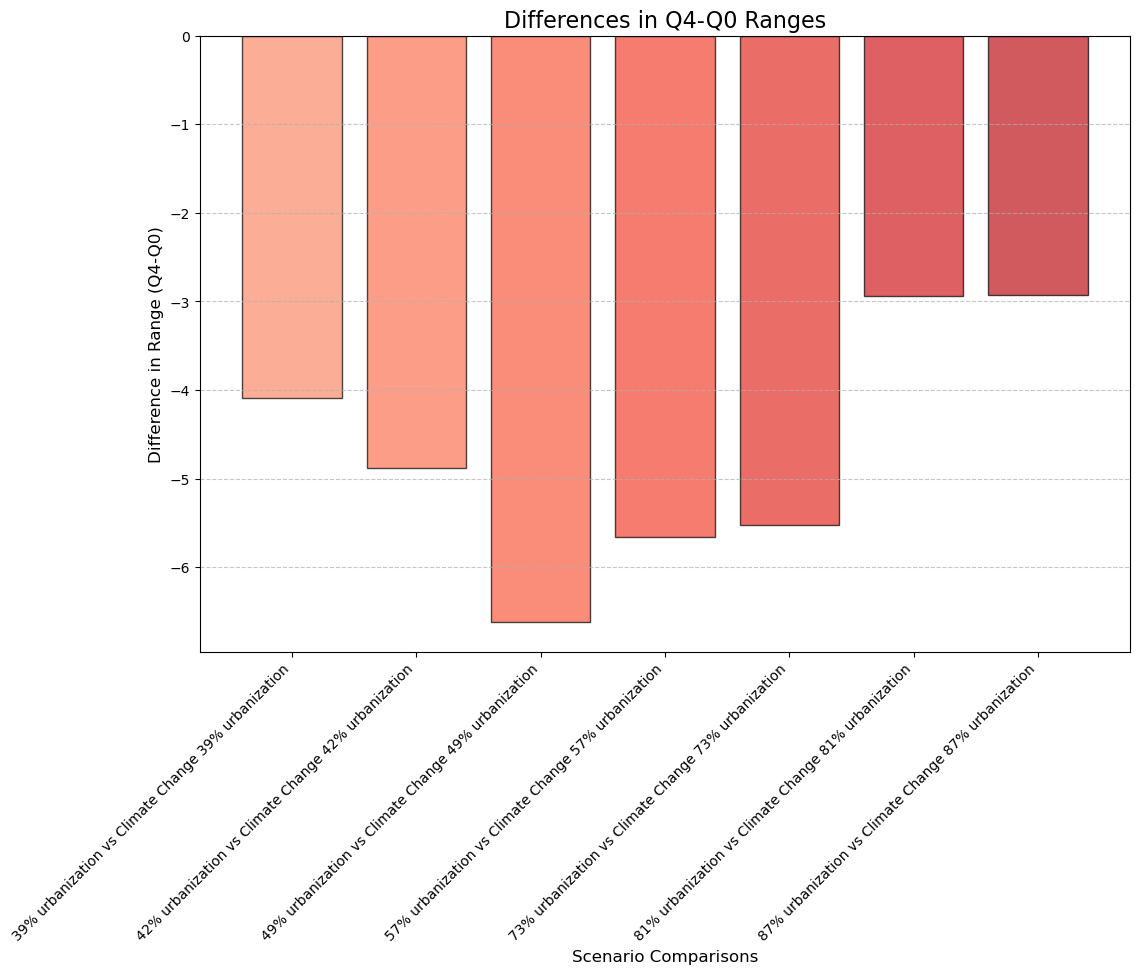

In [59]:

# Collect Q4 - Q0 ranges
scenario_labels = list(data_dict.keys())
scenario_ranges = [np.percentile(data['future'], 100) - np.percentile(data['future'], 95) for data in data_dict.values()]

# Calculate differences
half = len(scenario_ranges) // 2
difference_labels = [f'{scenario_labels[i]} vs {scenario_labels[i+half]}' for i in range(half)]
differences = [scenario_ranges[i+half] - scenario_ranges[i] for i in range(half)]

# Define colors
colors_climate_change = plt.cm.Reds(np.linspace(0.4, 0.8, half))
colors_no_climate_change = plt.cm.Blues(np.linspace(0.4, 0.8, half))
colors = []

for label in difference_labels:
    if 'climate change' in label.lower():
        colors.append(colors_climate_change[len(colors)])
    else:
        colors.append(colors_no_climate_change[len(colors)])

# Plot the differences
plt.figure(figsize=(12, 8))
plt.bar(difference_labels, differences, color=colors, alpha=0.7, edgecolor='black')

# Add titles, labels, and grid
plt.title('Differences in Q4-Q0 Ranges', fontsize=16)
plt.ylabel('Difference in Range (Q4-Q0)', fontsize=12)
plt.xlabel('Scenario Comparisons', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [55]:
differences

[-0.8687108174199238,
 -1.5859334922861308,
 -3.167972777504474,
 -0.15512041840702295,
 -0.9280334499198943,
 1.6464032719377428,
 1.5955628731753677]

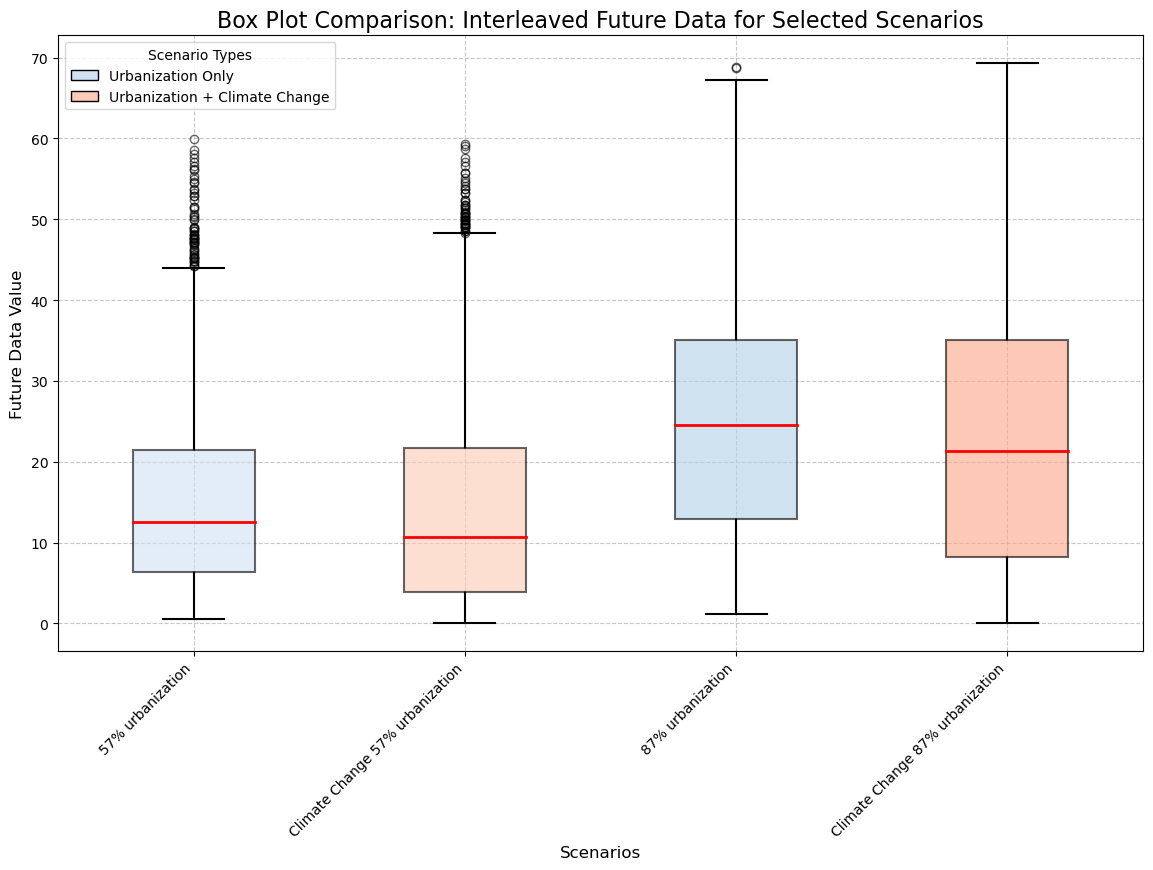

In [12]:
# Enhanced Box Plot Comparison for Selected Scenarios with Interleaved Order
title = 'Box Plot Comparison: Interleaved Future Data for Selected Scenarios'

# Selected scenarios in interleaved order
selected_scenarios = [
    '42% urbanization',
    'Climate Change 42% urbanization',
    '49% urbanization',
    'Climate Change 49% urbanization',
    '53% urbanization',
    'Climate Change 53% urbanization',
    '57% urbanization',
    'Climate Change 57% urbanization',
    '73% urbanization',
    'Climate Change 73% urbanization',
    '81% urbanization',
    'Climate Change 81% urbanization',
    '87% urbanization',
    'Climate Change 87% urbanization',
]

# Collect data for plotting based on selected scenarios
scenario_labels = []
scenario_values = []

for scenario in selected_scenarios:
    if scenario in data_dict:
        scenario_labels.append(scenario)
        scenario_values.append(data_dict[scenario]['future'])

# Define colors for scenarios
colors_climate_change = plt.cm.Reds(np.linspace(0.2, 0.9, len([s for s in selected_scenarios if 'Climate Change' in s])))
colors_no_climate_change = plt.cm.Blues(np.linspace(0.2, 0.9, len([s for s in selected_scenarios if 'Climate Change' not in s])))
colors = []

climate_change_index, no_climate_change_index = 0, 0
for label in scenario_labels:
    if 'Climate Change' in label:
        colors.append(colors_climate_change[climate_change_index])
        climate_change_index += 1
    else:
        colors.append(colors_no_climate_change[no_climate_change_index])
        no_climate_change_index += 1

plt.figure(figsize=(14, 8))

# Create the boxplot with custom colors
box = plt.boxplot(scenario_values, patch_artist=True, labels=scenario_labels,
                  boxprops=dict(color='black', linewidth=1.5),  # Box border
                  whiskerprops=dict(color='black', linewidth=1.5),  # Whisker line
                  capprops=dict(color='black', linewidth=1.5),  # Caps
                  medianprops=dict(color='red', linewidth=2),  # Median line
                  flierprops=dict(marker='o', color='black', alpha=0.6))  # Outliers

# Color the boxes
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)  # Slight transparency for better visibility

# Add titles, labels, and grid
plt.title(title, fontsize=16)
plt.ylabel('Future Data Value', fontsize=12)
plt.xlabel('Scenarios', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_no_climate_change[0], edgecolor='black', label='Urbanization Only'),
    Patch(facecolor=colors_climate_change[0], edgecolor='black', label='Urbanization + Climate Change'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, title='Scenario Types')

# Show the plot
plt.show()


In [22]:
# Select scenarios to compare
selected_scenarios = [
    '39% urbanization',
    '42% urbanization',
    '49% urbanization',
    '53 urbanization',
    '57% urbanization',
    '73% urbanization',
    '81% urbanization',
    '87% urbanization',
    'Climate Change 39% urbanization',
    'Climate Change 42% urbanization',
    'Climate Change 49% urbanization',
    'Climate Change 53% urbanization',    
    'Climate Change 57% urbanization',   
    'Climate Change 73% urbanization',
    'Climate Change 81% urbanization',
    'Climate Change 87% urbanization',
]

# Load and process data
data_dict = load_and_filter_data(sim_dir, selected_scenarios, 
                               rain_filter_threshold, shift_threshold)

# Create plot titles
dynamic_title = f"{historical_column[1].replace('_', ' ').title()} - {historical_column[2].replace('_', ' ').title()}"
x_label = f"{historical_column[2].replace('_', ' ').title()}"


number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8
number of events that filtered out: 8


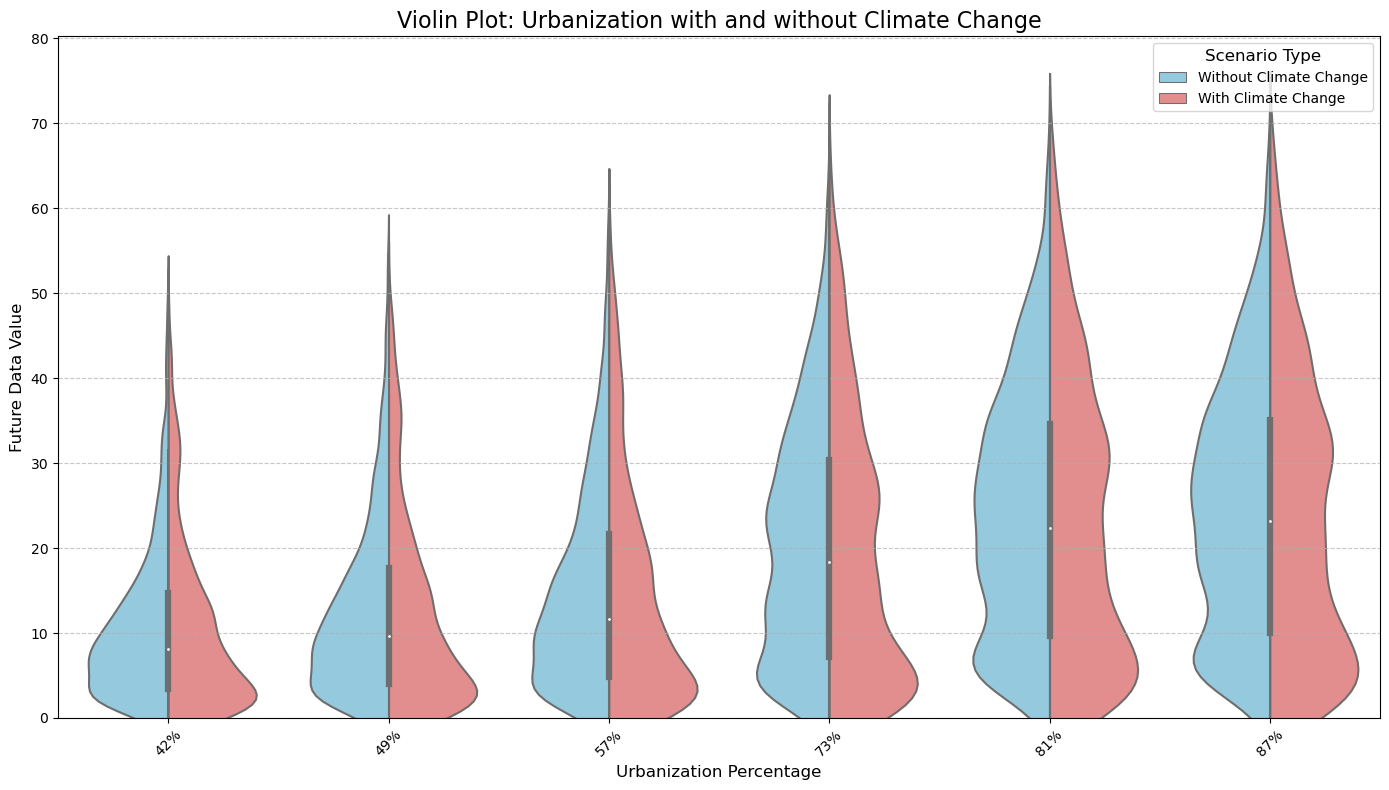

In [23]:
# Violin Plot: Split for Urbanization Scenarios with and without Climate Change
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Title and labels
title = 'Violin Plot: Urbanization with and without Climate Change'
y_label = 'Future Data Value'

# Selected scenarios
selected_scenarios = [
    ('42% urbanization', 'Climate Change 42% urbanization'),
    ('49% urbanization', 'Climate Change 49% urbanization'),
    ('53% urbanization', 'Climate Change 53% urbanization'),
    ('57% urbanization', 'Climate Change 57% urbanization'),
    ('73% urbanization', 'Climate Change 73% urbanization'),
    ('81% urbanization', 'Climate Change 81% urbanization'),
    ('87% urbanization', 'Climate Change 87% urbanization'),
]

# Prepare data for violin plot
data = {
    y_label: [],
    'Urbanization': [],
    'Type': [],
}

for urban_scenario, climate_scenario in selected_scenarios:
    if urban_scenario in data_dict and climate_scenario in data_dict:
        # Without Climate Change
        data[y_label].extend(data_dict[urban_scenario]['future'])
        data['Urbanization'].extend([urban_scenario.split('%')[0] + '%'] * len(data_dict[urban_scenario]['future']))
        data['Type'].extend(['Without Climate Change'] * len(data_dict[urban_scenario]['future']))
        
        # With Climate Change
        data[y_label].extend(data_dict[climate_scenario]['future'])
        data['Urbanization'].extend([urban_scenario.split('%')[0] + '%'] * len(data_dict[climate_scenario]['future']))
        data['Type'].extend(['With Climate Change'] * len(data_dict[climate_scenario]['future']))

# Convert to DataFrame
df = pd.DataFrame(data)

# Ensure there are no negative values
assert (df[y_label] >= 0).all(), "Data contains negative values!"

# Create the violin plot
plt.figure(figsize=(14, 8))
sns.violinplot(
    x='Urbanization',
    y=y_label,
    hue='Type',
    data=df,
    split=True,  # Split the violin into two halves
    palette={'Without Climate Change': 'skyblue', 'With Climate Change': 'lightcoral'}
)

# Add titles and labels
plt.title(title, fontsize=16)
plt.xlabel('Urbanization Percentage', fontsize=12)
plt.ylabel(y_label, fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title='Scenario Type', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis limits to avoid negative values
plt.ylim(bottom=0)

# Show the plot
plt.tight_layout()
plt.show()


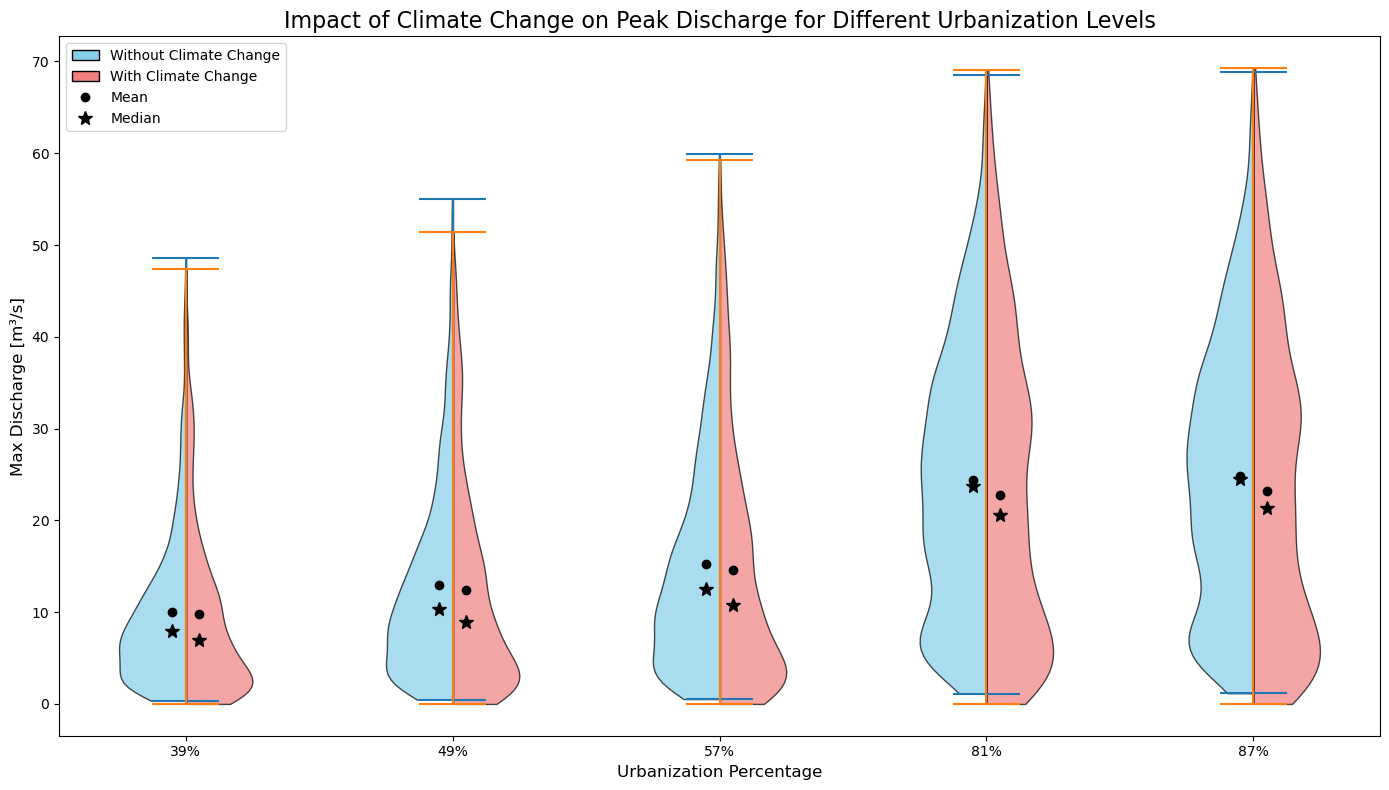

In [24]:
scenarios = ['39%','49%', '57%', '81%', '87%']
data_without_cc = [data_dict[f'{s} urbanization']['future'] for s in scenarios]
data_with_cc = [data_dict[f'Climate Change {s} urbanization']['future'] for s in scenarios]

fig, ax = plt.figure(figsize=(14, 8)), plt.gca()

def split_violin(data, positions, side):
    parts = plt.violinplot(data, positions, showmeans=False, showmedians=False)
    
    for pc in parts['bodies']:
        pc.set_facecolor('skyblue' if side == 'left' else 'lightcoral')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
        m = np.mean([pc.get_paths()[0].vertices[:, 0]])
        pc.get_paths()[0].vertices[:, 0] = np.clip(pc.get_paths()[0].vertices[:, 0], 
            -np.inf if side == 'left' else m, m if side == 'left' else np.inf)
    
    # Add means and medians
    for i, d in enumerate(data):
        if side == 'left':
            plt.plot(i - 0.05, np.mean(d), 'o', color='black', markersize=6)
            plt.plot(i - 0.05, np.median(d), '*', color='black', markersize=10)
        else:
            plt.plot(i + 0.05, np.mean(d), 'o', color='black', markersize=6)
            plt.plot(i + 0.05, np.median(d), '*', color='black', markersize=10)

positions = range(len(scenarios))
split_violin(data_without_cc, positions, 'left')
split_violin(data_with_cc, positions, 'right')

plt.title('Impact of Climate Change on Peak Discharge for Different Urbanization Levels', fontsize=16)
plt.xticks(positions, scenarios, rotation=0)
plt.ylabel('Max Discharge [m³/s]', fontsize=12)
plt.xlabel('Urbanization Percentage', fontsize=12)

legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Without Climate Change'),
    Patch(facecolor='lightcoral', edgecolor='black', label='With Climate Change'),
    plt.Line2D([0], [0], marker='o', color='black', label='Mean', markersize=6, linestyle='None'),
    plt.Line2D([0], [0], marker='*', color='black', label='Median', markersize=10, linestyle='None')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

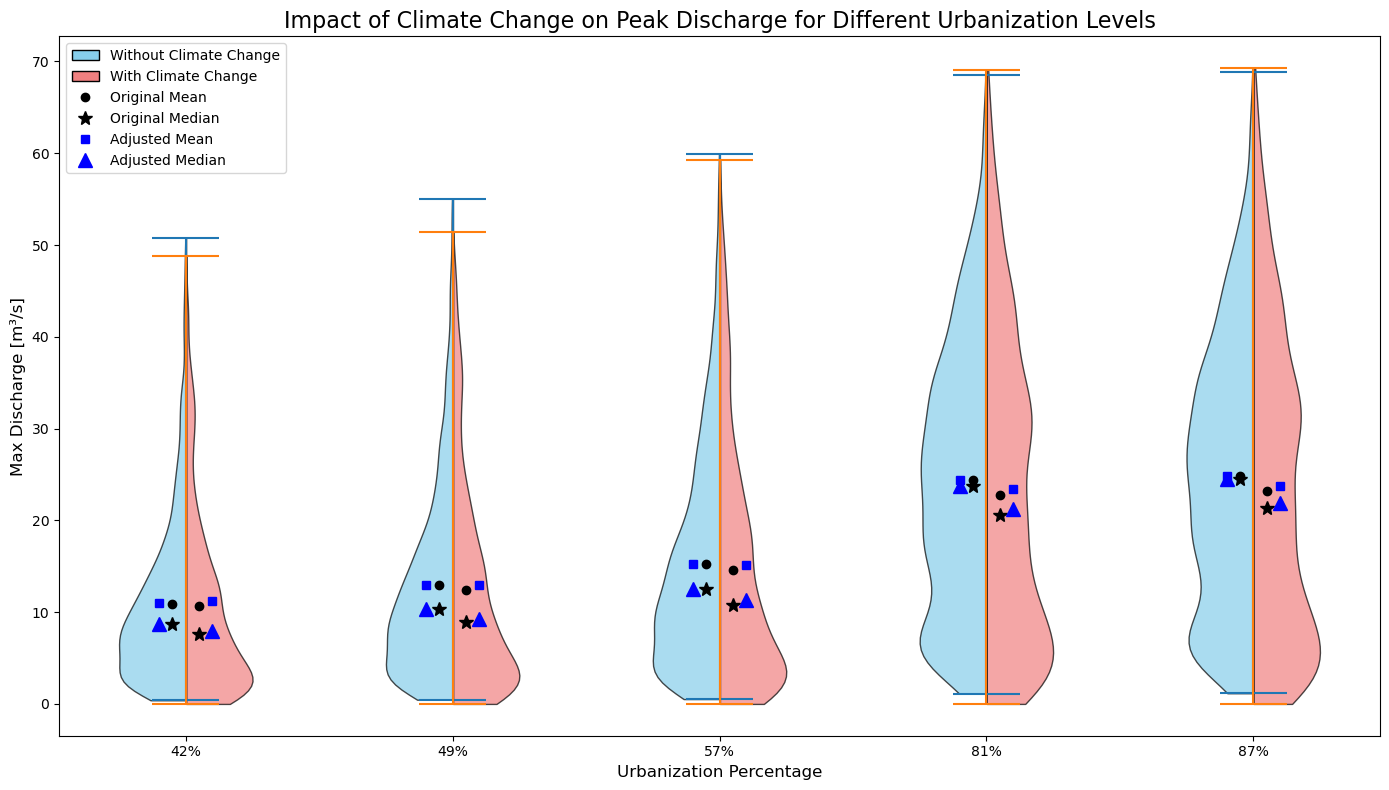

In [25]:
## filtered median and mean

scenarios = ['42%', '49%', '57%', '81%', '87%']
data_without_cc = [data_dict[f'{s} urbanization']['future'] for s in scenarios]
data_with_cc = [data_dict[f'Climate Change {s} urbanization']['future'] for s in scenarios]

fig, ax = plt.figure(figsize=(14, 8)), plt.gca()

def split_violin(data, positions, side):
    parts = plt.violinplot(data, positions, showmeans=False, showmedians=False)
    
    for pc in parts['bodies']:
        pc.set_facecolor('skyblue' if side == 'left' else 'lightcoral')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
        m = np.mean([pc.get_paths()[0].vertices[:, 0]])
        pc.get_paths()[0].vertices[:, 0] = np.clip(pc.get_paths()[0].vertices[:, 0], 
            -np.inf if side == 'left' else m, m if side == 'left' else np.inf)
    
    # Add means, medians, and adjusted values
    for i, d in enumerate(data):
        # Print all zero values
        zero_values = [x for x in d if x == 0]
        if zero_values:
            print(f"Scenario {scenarios[i]} ({'Without' if side == 'left' else 'With'} Climate Change):")
            print(f"Zero values: {zero_values}")

        # Original Mean and Median
        mean_orig = np.mean(d)
        median_orig = np.median(d)
        
        # Filter out zeros and calculate adjusted Mean and Median
        filtered_data = [x for x in d if x > 0.5]
        mean_filtered = np.mean(filtered_data) if filtered_data else None
        median_filtered = np.median(filtered_data) if filtered_data else None

        # Plot original mean and median
        x_shift = -0.05 if side == 'left' else 0.05
        plt.plot(i + x_shift, mean_orig, 'o', color='black', markersize=6, label=None)
        plt.plot(i + x_shift, median_orig, '*', color='black', markersize=10, label=None)

        # Plot adjusted mean and median after removing zeros
        x_shift_filtered = -0.1 if side == 'left' else 0.1  # Shifted further for distinction
        if mean_filtered is not None:
            plt.plot(i + x_shift_filtered, mean_filtered, 's', color='blue', markersize=6, label=None)  # Square for adjusted mean
        if median_filtered is not None:
            plt.plot(i + x_shift_filtered, median_filtered, '^', color='blue', markersize=10, label=None)  # Triangle for adjusted median

positions = range(len(scenarios))
split_violin(data_without_cc, positions, 'left')
split_violin(data_with_cc, positions, 'right')

# Title, labels, and legend
plt.title('Impact of Climate Change on Peak Discharge for Different Urbanization Levels', fontsize=16)
plt.xticks(positions, scenarios, rotation=0)
plt.ylabel('Max Discharge [m³/s]', fontsize=12)
plt.xlabel('Urbanization Percentage', fontsize=12)
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Without Climate Change'),
    Patch(facecolor='lightcoral', edgecolor='black', label='With Climate Change'),
    plt.Line2D([0], [0], marker='o', color='black', label='Original Mean', markersize=6, linestyle='None'),
    plt.Line2D([0], [0], marker='*', color='black', label='Original Median', markersize=10, linestyle='None'),
    plt.Line2D([0], [0], marker='s', color='blue', label='Adjusted Mean', markersize=6, linestyle='None'),
    plt.Line2D([0], [0], marker='^', color='blue', label='Adjusted Median', markersize=10, linestyle='None')
]
plt.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()
